In [1]:
!pip install pykeops
!pip install -qq "git+https://github.com/christpaul94/MD1912.git#subdirectory=MolecularDynamics"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 42.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 23.6 MB/s eta 0:00:00
  Created wheel for pykeops: filename=pykeops-2.3-py3-none-any.whl size=120491 sha256=9863e5177a0d60e43ecee4704b9f0e601df7a9dd1bdeb091d9aed3958c0de45d
  Stored in directory: /root/.cache/pip/wheels/b0/ac/34/a732caf88f9754536a4e2389a3f08c035ad33c0ae6f4cfbc38
  Created wheel for keopscore: filename=keopscore-2.3-py3-none-any.whl size=185897 sha256=71fed97cc8b6dae66944c7f9a0635809b1f60b0fbfe33ba6fb6b6802c6196081
  Stored in directory: /root/.cache/pip/wheels/4f/f8/36/9335901e1bdbd1b6c466d8f33800f66f09c60e457ebc921d29
Successfully built pykeops keopscore
  Preparing metadata (setup.py) ... done


In [2]:
# Algorithm: Triton Simple N-Body Kernel
# Input: Positions Q, Parameters (V0, sigma)
# Output: Forces F

# Parallel for each particle i from 0 to N-1 (Grid ID):
#     // 1. Load data to registers
#     Load q_i from Global Memory into Registers
#     Initialize Accumulator F_i = (0, 0, 0)

#     // 2. Stream neighbor particles in blocks
#     For j_start from 0 to N with step BLOCK_SIZE:
#         // Load a block of j particles
#         Load Q_block from Global Memory [j_start : j_start + BLOCK_SIZE]

#         // Vectorized computation in Registers
#         Calculate distance vectors D = q_i - Q_block
#         Calculate squared distances R2 = sum(D^2)
#         Calculate Force Magnitude M = exp(-R2 / (2*sigma^2)) * (V0/sigma^2)

#         // Accumulate
#         F_i += sum(D * M)

#     // 3. Store result
#     Store F_i to Global Memory

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


Device: cuda
N Werte: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]

Benchmarking N=2...
[KeOps] Generating code for Sum_Reduction reduction (with parameters 0) of formula Exp(-Sum((a-b)**2)/c)*(a-b) with a=Var(0,3,0), b=Var(1,3,1), c=Var(2,1,2) ... OK
Benchmarking N=4...
Benchmarking N=8...
Benchmarking N=16...
Benchmarking N=32...
Benchmarking N=64...
Benchmarking N=128...
Benchmarking N=256...
Benchmarking N=512...


W0209 22:17:16.510000 3197 torch/_dynamo/convert_frame.py:1358] [0/8] torch._dynamo hit config.recompile_limit (8)
W0209 22:17:16.510000 3197 torch/_dynamo/convert_frame.py:1358] [0/8]    function: 'pytorch_chunked_DxN' (/usr/local/lib/python3.12/dist-packages/TrappedAtomsSimulation/nbody_force_kernels.py:82)
W0209 22:17:16.510000 3197 torch/_dynamo/convert_frame.py:1358] [0/8]    last reason: 0/7: tensor 'q' size mismatch at index 1. expected 256, actual 512
W0209 22:17:16.510000 3197 torch/_dynamo/convert_frame.py:1358] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0209 22:17:16.510000 3197 torch/_dynamo/convert_frame.py:1358] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html


Benchmarking N=1024...
Benchmarking N=2048...
Benchmarking N=4096...
Benchmarking N=8192...
Benchmarking N=16384...
Benchmarking N=32768...
Benchmarking N=65536...


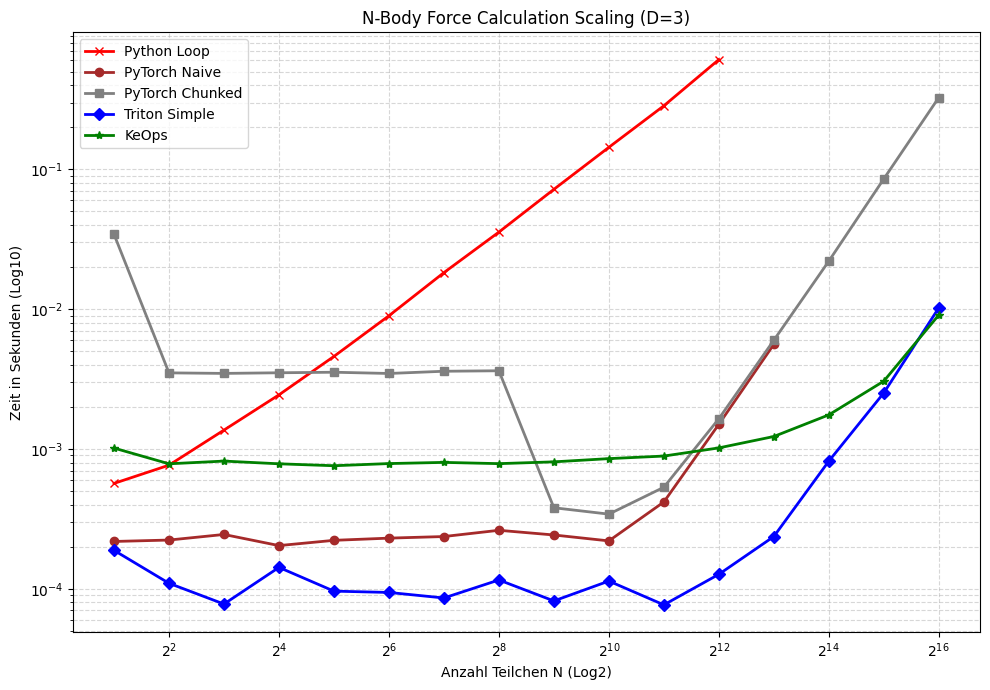

In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import gc
import numpy as np

# Import
from TrappedAtomsSimulation.nbody_force_kernels import (
    loop_DxN,
    naive_DxN,
    pytorch_chunked_DxN,
    triton_simple_DxN,
    keops_DxN
)

# --- KONFIGURATION ---
torch.set_float32_matmul_precision('high')
device = 'cuda'
D = 3
r0 = 1.0
c = 1.0


N_list = [2**x for x in range(1, 17)]

# --- ALGORITHMEN ---
algos = [
    # (Name, Funktion, Farbe, Marker)
    ("Python Loop",     loop_DxN,            "red",    "x"),
    ("PyTorch Naive",   naive_DxN,           "brown",  "o"),
    ("PyTorch Chunked", pytorch_chunked_DxN, "gray",   "s"),
    ("Triton Simple",   triton_simple_DxN,   "blue",   "D"),
    ("KeOps",           keops_DxN,           "green",  "*"),
]


print(f"Device: {device}")
print(f"N Werte: {N_list}\n")

results = []

# --- HAUPTSCHLEIFE ÜBER N ---
for N in N_list:
    print(f"Benchmarking N={N}...")

    q = torch.randn(D, N, device=device, dtype=torch.float32)


    for name, func, color, marker in algos:
# skip some
        if "Loop" in name and N > 4096:
            continue
        if "Naive" in name and N > 8192:
            continue

        # Garbage Collection
        gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()

        # Chunk
        if "Chunked" in name:
            c_size = 2**10
        else:
            c_size = None

        # Messung
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        runs = 1 #if ("Loop" in name or "Naive" in name) else 5

        try:
            func(q, r0, c, chunk=c_size)
            torch.cuda.synchronize()

            # Timing
            start_event.record()
            for _ in range(runs):
                func(q, r0, c, chunk=c_size)
            end_event.record()
            torch.cuda.synchronize()

            t_sec = (start_event.elapsed_time(end_event) / runs) / 1000.0

            results.append({
                "N": N,
                "Algo": name,
                "Time": t_sec,
                "Color": color,
                "Marker": marker
            })


        except RuntimeError as e:
            print(f"  -> {name}: Out of Memory)")
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"  -> {name}: Fehler {e}")

    # q löschen für den nächsten Durchlauf
    del q

# --- PLOTTING ---

df = pd.DataFrame(results)

plt.figure(figsize=(10, 7))

for name in df["Algo"].unique():
    subset = df[df["Algo"] == name]
    color = subset.iloc[0]["Color"]
    marker = subset.iloc[0]["Marker"]

    plt.plot(subset["N"], subset["Time"], label=name, color=color, marker=marker, linewidth=2)

plt.xscale('log', base=2)
plt.yscale('log', base=10)

plt.xlabel("Anzahl Teilchen N (Log2)")
plt.ylabel("Zeit in Sekunden (Log10)")
plt.title(f"N-Body Force Calculation Scaling (D={D})")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)


plt.tight_layout()
plt.show()

Running Consistency Check on NVIDIA A100-SXM4-80GB...
 -> Full Tensor         : Diff = 3.05e-05
 -> Batched Tensor      : Diff = 3.05e-05
 -> Triton Kernel       : Diff = 3.15e-05
 -> KeOps               : Diff = 3.96e-05

Starting Benchmark...
Measuring N=16...
Measuring N=32...
Measuring N=64...
Measuring N=128...
Measuring N=256...
Measuring N=512...
Measuring N=1024...
Measuring N=2048...
Measuring N=4096...
Measuring N=8192...
Measuring N=16384...
Measuring N=32768...
Measuring N=65536...
Measuring N=131072...
Measuring N=262144...
Measuring N=524288...


--- RESULTS FOR LATEX TABLE (COPY THIS) ---
N               | Batched Tensor  | Full Tensor     | KeOps           | Sequential      | Triton Kernel  
---------------------------------------------------------------------------------------------------------
16              | 0.37 ms         | 0.25 ms         | 0.83 ms         | 2 ms            | 0.11 ms        
32              | 0.33 ms         | 0.27 ms         | 0.81 ms         |

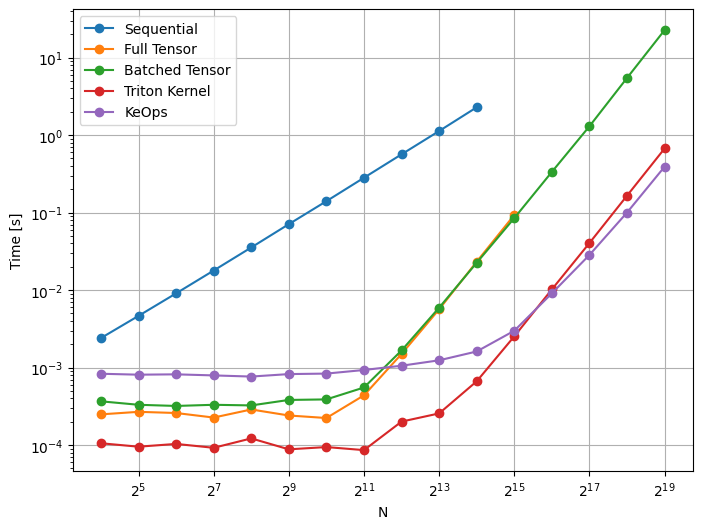

In [12]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import gc
import numpy as np

# Import deiner Kernel
# Falls Funktionsnamen anders sind, bitte hier anpassen!
from TrappedAtomsSimulation.nbody_force_kernels import (
    loop_DxN,
    naive_DxN,
    pytorch_chunked_DxN,
    triton_simple_DxN,
    keops_DxN
)


# --- KONFIGURATION ---
torch.set_float32_matmul_precision('high')
device = 'cuda'
D = 3
r0 = 1.0
c = 1.0

# --- ALGORITHMEN ---
# Namen müssen exakt mit dem späteren Pivot-Schritt übereinstimmen
# --- ALGORITHMEN (Namen angepasst, Funktionen alt) ---
algos = [
    ("Sequential",    loop_DxN,             "red",    "x"),
    ("Full Tensor",         naive_DxN,            "brown",  "o"),
    ("Batched Tensor",      pytorch_chunked_DxN,  "gray",   "s"),
    ("Triton Kernel",       triton_simple_DxN,    "blue",   "D"),
    ("KeOps",      keops_DxN,            "green",  "*"),
]

# ============================================================================
# 1. CONSISTENCY CHECK (Kurz)
# ============================================================================
print(f"Running Consistency Check on {torch.cuda.get_device_name(0)}...")
q_val = torch.randn(D, 1000, device=device)
F_ref = loop_DxN(q_val, r0, c)
for name, func, _, _ in algos:
    if "Sequential" in name: continue
    chunk_arg = 1024 if "Batched" in name else None
    try:
        F_algo = func(q_val, r0, c, chunk=chunk_arg)
        diff = torch.norm(F_ref - F_algo, dim=0).max().item()
        print(f" -> {name:<20}: Diff = {diff:.2e}")
    except Exception as e:
        print(f" -> {name:<20}: FAILED ({e})")
del q_val, F_ref, F_algo
gc.collect(); torch.cuda.empty_cache()

# ============================================================================
# 2. PERFORMANCE BENCHMARK
# ============================================================================
print("\nStarting Benchmark...")
# Wir testen typische N für die Tabelle: 1k, 10k, sowie die Grenzen
N_list = [2**x for x in range(4, 20)]
results = []

for N in N_list:
    print(f"Measuring N={N}...")
    q = torch.randn(D, N, device=device)

    for name, func, color, marker in algos:
        # Skip Logic
        if "Sequential" in name and N > 4096*4: continue
        if "Full Tensor" in name and N > 16384*4: continue # OOM Schutz anpassen je nach GPU VRAM!

        gc.collect(); torch.cuda.empty_cache()
        c_size = 1024 if "Batched" in name else None

        try:
            # Warmup
            func(q, r0, c, chunk=c_size)
            torch.cuda.synchronize()

            # Timing
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
            func(q, r0, c, chunk=c_size)
            end.record()
            torch.cuda.synchronize()
            t_sec = start.elapsed_time(end) / 1000.0

            results.append({"N": N, "Algo": name, "Time": t_sec})
        except RuntimeError:
            results.append({"N": N, "Algo": name, "Time": "OOM"})
        except Exception:
            results.append({"N": N, "Algo": name, "Time": "ERR"})

    del q

# ============================================================================
# 3. DATA EXPORT FOR LATEX
# ============================================================================
print("\n\n" + "="*80)
print("--- RESULTS FOR LATEX TABLE (COPY THIS) ---")
print("="*80)

# Pivot Daten für schöne Tabelle
df = pd.DataFrame(results)
pivot = df.pivot(index="N", columns="Algo", values="Time")

# Header
headers = ["N"] + list(pivot.columns)
header_str = " | ".join([f"{h:<15}" for h in headers])
print(header_str)
print("-" * len(header_str))

# Rows
for n_val in N_list:
    if n_val not in pivot.index: continue
    row = pivot.loc[n_val]
    row_str = f"{str(n_val):<15}"
    for col in pivot.columns:
        val = row[col]
        if isinstance(val, float):
            # Formatierung: ms oder s
            if val < 0.001: val_str = f"{val*1000:.2f} ms" # < 1ms
            elif val < 1.0: val_str = f"{val*1000:.0f} ms"
            else:           val_str = f"{val:.2f} s"
        else:
            val_str = str(val) if pd.notna(val) else "--"
        row_str += f" | {val_str:<15}"
    print(row_str)
print("="*80 + "\n")

# Plotting für das PDF
plt.figure(figsize=(8, 6))
for name in df["Algo"].unique():
    subset = df[(df["Algo"] == name) & (df["Time"] != "OOM")]
    # Konvertiere Time zurück zu float für Plot
    subset = subset.copy()
    subset["Time"] = pd.to_numeric(subset["Time"], errors='coerce')
    plt.plot(subset["N"], subset["Time"], label=name, marker='o')

plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel("N")
plt.ylabel("Time [s]")
plt.legend()
plt.grid(True)
plt.savefig("scaling_benchmark.pdf")
print("Plot saved as scaling_benchmark.pdf")

# potential plot

Plot gespeichert als potential_comparison_symbolic.pdf


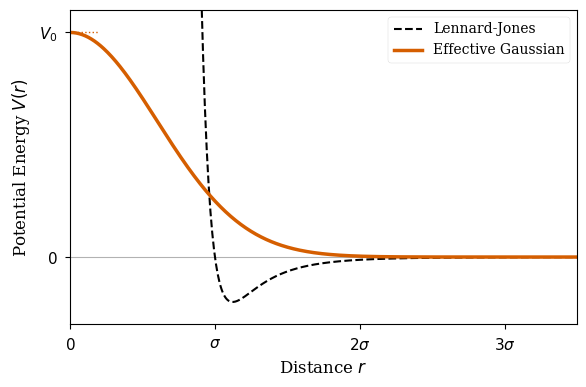

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Plotting Style ---
plt.style.use('seaborn-v0_8-paper')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.figsize': (6, 4)
})

# --- Daten ---
# Gauß startet bei 0 für den Gipfel
r_gauss = np.linspace(0.0, 3.5, 500)
# LJ startet später wegen Singularität
r_lj = np.linspace(0.35, 3.5, 500)

# Parameter (Werte sind jetzt egal, da wir sie symbolisch beschriften)
V0_gauss = 5.0
width_gauss = 0.6

# Berechnung
v_gauss = V0_gauss * np.exp(-(r_gauss)**2 / (2 * width_gauss**2))
v_lj = 4 * ((1/r_lj)**12 - (1/r_lj)**6)
v_lj[v_lj > 20] = np.nan

# --- Plotten ---
fig, ax = plt.subplots()

# 1. Nulllinie
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# 2. Kurven
ax.plot(r_lj, v_lj, 'k--', linewidth=1.5, label=r'Lennard-Jones')
ax.plot(r_gauss, v_gauss, color='#D55E00', linewidth=2.5, label=r'Effective Gaussian')

# --- DAS IST NEU: Symbolische Achsen ---

# Y-Achse: Nur 0 und V0 anzeigen
ax.set_yticks([0, V0_gauss])
ax.set_yticklabels([r'$0$', r'$V_0$'])

# Hilfslinie von der Y-Achse zum Gauß-Gipfel
ax.hlines(y=V0_gauss, xmin=0, xmax=0.2, color='#D55E00', linestyle=':', linewidth=1.0)


# X-Achse: Nur 0 und sigma anzeigen (Optional, aber konsequent)
# Wir setzen sigma da hin, wo r/sigma = 1 ist.
ax.set_xticks([0, 1.0, 2.0, 3.0])
ax.set_xticklabels([r'$0$', r'$\sigma$', r'$2\sigma$', r'$3\sigma$'])


# --- Labels & Layout ---
ax.set_xlabel(r'Distance $r$', labelpad=5)
ax.set_ylabel(r'Potential Energy $V(r)$', labelpad=5)

ax.set_ylim(-1.5, V0_gauss * 1.1) # Etwas Luft nach oben
ax.set_xlim(0, 3.5)

ax.legend(frameon=True, facecolor='white', framealpha=1, loc='upper right')
ax.grid(False) # Grid aus, sieht bei symbolischen Plots oft besser aus

plt.tight_layout()

# Speichern
output_filename = 'potential_comparison_symbolic.pdf'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Plot gespeichert als {output_filename}")
plt.show()